In [14]:
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

from typing import Literal, Annotated, List, Any
from IPython.display import Image, display
from jinja2 import Template
from operator import add
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage
from langgraph.types import Send
from langchain_openai import ChatOpenAI
import openai
import pandas as pd
from qdrant_client import QdrantClient, models

from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

from ast import MatchValue
from tracemalloc import Filter
import cohere
from langsmith import traceable, get_current_run_tree
import instructor
from api.agents.utils.prompt_management import prompt_template_config

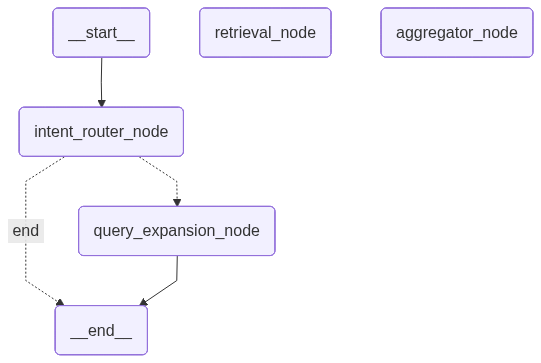

In [27]:
class State(BaseModel):
    expanded_query: List[str] = []
    # add is the reducer.... If running retrieval from differnet nodes we need to have Annotated i.e reduced and not verwritten on every node execution
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = "" # populated once we perform the generation based on the retrieved context
    question_relevant: bool = False
    query: str = ""
    k: int = 10

class QueryExpendResponse(BaseModel):
    statements: List[str] = Field(description="List of statements that break down the original query into sub-queries")


@traceable(
    name="Query Expansion Node", 
    run_type = 'llm',
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini",
    }
)
def query_expansion_node(state: State) -> dict:
    prompt_template = """
        You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.
        ## Instructions

        - Expand the question into 1-5 concise statements.
        - Each statement should capture a separate product or attribute from the query.
        - Use natural product-description language.
        - Do not produce multiple statements that express the same intent.

        ## Examples

        Question: "Can I get earphones for me and a waterproof speaker?"
        Statements:
        - "Personal earphones"
        - "Waterproof speaker"

        Question: "I need a warm winter jacket for hiking"
        Statements:
        - "Insulated winter jacket"
        - "Hiking outerwear for cold weather"

        Question: "Do you have any toys?"
        Statements:
        - "Toys"

            <question>
            {{ query }}
            </question>
        """
        
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    
    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model = QueryExpendResponse
    )
    
    return {
        "expanded_query": response.statements,
    }


def query_expand_conditional_edges(state: State) -> dict:
    send_messages = []
    for query in state.expanded_query:
        send_messages.append(Send("retrieval_node", {"query": query, "k": state.k}))
    return send_messages

@traceable(
    name="embed_query",
    run_type="embedding", # tells langsmith we are actually running embedding text -> specific set of vectors
    metadata={
        "ls_provider": "openai", 
              "model": "text-embedding-3-small"
    } ## langsmith needs this to calculate cost of runs
)
def get_embedding(text):
    response = openai.embeddings.create( # was client before
        input=text,
        model="text-embedding-3-small"
    )
    
    current_run  = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }
    return response.data[0].embedding

@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict: # 5 most similar items to users query
    query = state["query"]
    k = state["k"]
    embedding = get_embedding(query) # so we are actually creating related vector here
    qdrant_client = QdrantClient(url="http://localhost:6333")
    hybrid = True
    
    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=embedding,
                    using='text-embedding-3-small', #name of the vector in the collection
                    limit=20
                ), 
                Prefetch(
                    query=Document(text=query, model='qdrant/bm25'),
                    using='bm25', #name of the vector in the collection
                    limit=20
                )
            ],
            # can set specific weights on how much importance we put on dense embeddings and bm25 lexical retrievals
            # in this case dense vector retrival is weighted as 3 times more important than bm25
            # if user queries are more keyword-based, you might want to increase the weight of bm25
            # if more contextual then you might want to increase the weight of the dense vector retrieval
            # weights can be added as params to the retrieve data function
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])), # how you fuse the results....
            limit=k # once fused we are returning top k results
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=embedding,
            using='text-embedding-3-small',
            limit=k
        )
    
    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []
    
    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload.get("preprocessed_description"))
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload.get("average_rating"))
        
    formatted_context = ""
    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
    
    return {
        "retrieved_context": [formatted_context]
    }
    

class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the user's question based on the retrieved context")

@traceable(
    name="generate_answer", 
    run_type = 'llm',
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini",
    }
)
def aggregator_node(state: State) -> dict:
    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """
        You are a shopping assistant.

        Task:
        1) Read the user question and extract the distinct requested entities (product categories) it mentions.
        2) For each entity, list ONLY the product names from the available products that match that entity.

        Rules:
        - Use ONLY the available products below. Do not invent products.
        - The entity heading MUST appear before the product list for that entity.
        - Output format MUST be:
        <ENTITY>: <short phrase from the question that indicates the entity>
        - <Product Name>
        (blank line)
        - Only output product names (no prices/specs).
        - If an entity has no matching products, write:
        - NO_MATCHES
        - Do not include duplicates within an entity.

        User question:
        {{ question }}

        Available products:
        {{ preprocessed_context }}
    """
        
    template = Template(prompt_template)
    prompt = template.render(preprocessed_context=preprocessed_context, question=state.initial_query)
    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    
    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model = AggregatorResponse
    )
    
    return {
        "answer": response.answer # in answer due to response schema
    }


#### User intent router node

class IntentRouterResponse(BaseModel):
    question_relevant: bool = Field(description="Whether the user's question is relevant to the products in the database")
    answer: str = Field(description="A brief explanation of why the question is relevant or not.")

@traceable(
    name="route_intent", 
    run_type = 'llm',
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini",
    }
)
def intent_router_node(state: State) -> dict:
    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.
        ## Instructions

        - Determine whether the question is about products, inventory, or purchasing.
        - Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
        - Questions about store policies, personal advice, or unrelated topics are not relevant.

        ## Examples

        Question: "Do you have running shoes under $100?"
        Relevant: yes

        Question: "What's the weather like today?"
        Relevant: no - not related to products

        Question: "Can you help me write an essay?"
        Relevant: no - not related to products

        Question: "Which laptop has the best battery life?"
        Relevant: yes

        Question: "What's your return policy?"
        Relevant: no - about store policy, not product information

        <question>
        {{ query }}
        </question>
    """
        
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    
    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model = IntentRouterResponse
    )
    
    print("Intent Router Response:", response)
    
    return {
        "question_relevant": response.question_relevant, # pydantic class
        "answer": response.answer
    }
    
def intent_router_conditional_edges(state: State) -> dict:
    if state.question_relevant:
        return "query_expansion_node"
    else:
        return "end"

    
    
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retrieval_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges("intent_router_node", intent_router_conditional_edges, {
    "query_expansion_node": "query_expansion_node",
    "end": END
})

workflow.add_conditional_edges("query_expansion_node", query_expand_conditional_edges)
workflow.add_edge("retrieval_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

# compile the graph
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [28]:
initial_state = {
    "initial_query": "How many times should I be walking my dog"
}
result = graph.invoke(initial_state)

Intent Router Response: question_relevant=False answer='The question is about dog walking frequency/health advice, not about any product catalog, inventory, pricing, or purchasing.'


In [29]:
print(result["answer"])

The question is about dog walking frequency/health advice, not about any product catalog, inventory, pricing, or purchasing.
